In [1]:
import zipfile
import os

zip_path = r"C:\Users\thash\Downloads\archive (2).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("marketing_data")

print("Files extracted successfully!")
print(os.listdir("marketing_data"))

Files extracted successfully!
['Marketing campaign dataset.csv']


In [2]:
import pandas as pd
df = pd.read_csv("marketing_data/Marketing campaign dataset.csv")
df.head()

,campaign_item_id,no_of_days,time,ext_service_id,ext_service_name,creative_id,creative_width,creative_height,search_tags,template_id,...,exchange_rate,media_cost_usd,position_in_content,unique_reach,total_reach,search_tag_cat,cmi_currency_code,timezone,weekday_cat,keywords
0,2733,7,2022-05-01,128,Facebook Ads,1000,300.0,250.0,#The Power of X,90.0,...,1,14.058514,NaN,NaN,NaN,Others,SGD,Asia/Singapore,week_end,delicate bracelets
1,2733,8,2022-05-02,16,DV360,1000,300.0,250.0,#Be Bold. Be X,90.0,...,1,99.633496,NaN,NaN,NaN,Others,SGD,Asia/Singapore,week_day,summer jewelry
2,2733,9,2022-05-03,128,Facebook Ads,1000,300.0,250.0,#Embrace Your Individuality with X,90.0,...,1,109.419677,NaN,NaN,NaN,Others,SGD,Asia/Singapore,week_day,artisan jewelry
3,2733,10,2022-05-04,128,Facebook Ads,1000,300.0,250.0,#Be Bold. Be X,90.0,...,1,115.209499,NaN,NaN,NaN,Others,SGD,Asia/Singapore,week_day,layered bracelets
4,2733,11,2022-05-05,4,Google Ads,1000,300.0,250.0,#Be Bold. Be X,90.0,...,1,66.990104,NaN,NaN,NaN,Others,SGD,Asia/Singapore,week_day,minimalist jewelry


In [3]:
# Number of rows and columns
print("Dataset shape:", df.shape)

# Column names
print("\nColumn names:")
print(df.columns.tolist())

# Basic information
print("\nDataset information:")
df.info()

Dataset shape: (72612, 35)

Column names:
['campaign_item_id', 'no_of_days', 'time', 'ext_service_id', 'ext_service_name', 'creative_id', 'creative_width', 'creative_height', 'search_tags', 'template_id', 'landing_page', 'advertiser_id', 'advertiser_name', 'network_id', 'approved_budget', 'advertiser_currency', 'channel_id', 'channel_name', 'max_bid_cpm', 'network_margin', 'campaign_budget_usd', 'impressions', 'clicks', 'stats_currency', 'currency_code', 'exchange_rate', 'media_cost_usd', 'position_in_content', 'unique_reach', 'total_reach', 'search_tag_cat', 'cmi_currency_code', 'timezone', 'weekday_cat', 'keywords']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 72612 entries, 0 to 72611
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   campaign_item_id     72612 non-null  int64  
 1   no_of_days           72612 non-null  int64  
 2   time                 72612 non-null  str    
 3  

In [4]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values[missing_values > 0])

Missing values in each column:
creative_width          3412
creative_height         3412
template_id             3412
approved_budget          406
max_bid_cpm            65206
position_in_content    72612
unique_reach           72612
total_reach            72612
dtype: int64


In [5]:
# Check duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [6]:
# Check number of unique values in important categorical columns
print("Marketing channels:")
print(df["ext_service_name"].value_counts())

print("\nChannel names:")
print(df["channel_name"].value_counts())

Marketing channels:
ext_service_name
Facebook Ads    24275
DV360           24171
Google Ads      24166
Name: count, dtype: int64

Channel names:
channel_name
Mobile     14625
Social     14576
Video      14525
Display    14447
Search     14439
Name: count, dtype: int64


In [7]:
# Remove columns with no values and columns with too many missing values
df = df.drop(columns=[
    "position_in_content",
    "unique_reach",
    "total_reach",
    "max_bid_cpm"
])

print("Columns after removal:", df.shape[1])

Columns after removal: 31


In [8]:
df["time"] = pd.to_datetime(df["time"])
print(df["time"].dtype)

datetime64[us]


In [9]:
print(df.isnull().sum()[df.isnull().sum() > 0])

creative_width     3412
creative_height    3412
template_id        3412
approved_budget     406
dtype: int64


In [12]:
df["creative_width"] = df["creative_width"].fillna(
    df["creative_width"].median()
)

df["creative_height"] = df["creative_height"].fillna(
    df["creative_height"].median()
)

df["template_id"] = df["template_id"].fillna(
    df["template_id"].median()
)

df["approved_budget"] = df["approved_budget"].fillna(
    df["approved_budget"].median()
)

In [13]:
print("Remaining missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nDataset shape:", df.shape)

print("\nDuplicate rows:", df.duplicated().sum())

Remaining missing values:
Series([], dtype: int64)

Dataset shape: (72612, 31)

Duplicate rows: 0


In [14]:
print(df[[
    "approved_budget",
    "campaign_budget_usd",
    "impressions",
    "clicks",
    "media_cost_usd",
    "network_margin"
]].describe())

       approved_budget  campaign_budget_usd    impressions        clicks  \
count     7.261200e+04         72612.000000   72612.000000  72612.000000   
mean      1.251589e+05           617.630284    1370.161847     52.696386   
std       5.611117e+05          1354.606619    3702.699962    377.308103   
min       4.000000e+02             2.452316     511.000000      2.000000   
25%       6.000000e+03           205.994550     526.000000      5.000000   
50%       1.000000e+04           377.656676     577.000000      8.000000   
75%       1.500000e+04           755.313351     816.000000     13.000000   
max       6.000000e+06         39559.896155  153959.000000  31807.000000   

       media_cost_usd  network_margin  
count    72612.000000         72612.0  
mean        11.819999             0.0  
std         48.370659             0.0  
min          0.000000             0.0  
25%          0.435791             0.0  
50%          1.709001             0.0  
75%          8.276369             0

In [15]:
print("Negative impressions:", (df["impressions"] < 0).sum())
print("Negative clicks:", (df["clicks"] < 0).sum())
print("Negative media cost:", (df["media_cost_usd"] < 0).sum())
print("Negative budget:", (df["campaign_budget_usd"] < 0).sum())

Negative impressions: 0
Negative clicks: 0
Negative media cost: 0
Negative budget: 0


In [16]:
print(
    "Clicks greater than impressions:",
    (df["clicks"] > df["impressions"]).sum()
)

Clicks greater than impressions: 9


In [17]:
print("Start date:", df["time"].min())
print("End date:", df["time"].max())

Start date: 2022-05-01 00:00:00
End date: 2022-12-10 00:00:00


In [18]:
invalid_rows = df[df["clicks"] > df["impressions"]]
print("Invalid rows:", len(invalid_rows))

Invalid rows: 9


In [19]:
df = df[df["clicks"] <= df["impressions"]].copy()
print("New dataset shape:", df.shape)

New dataset shape: (72603, 31)


In [20]:
print("Clicks greater than impressions:",
      (df["clicks"] > df["impressions"]).sum())

Clicks greater than impressions: 0


In [21]:
# Calculate marketing performance metrics

df["CTR"] = (df["clicks"] / df["impressions"]) * 100

df["CPC"] = df["media_cost_usd"] / df["clicks"]

df["CPM"] = (df["media_cost_usd"] / df["impressions"]) * 1000

df["Budget_Utilization"] = (
    df["media_cost_usd"] / df["campaign_budget_usd"]
) * 100

In [22]:
df[[
    "ext_service_name",
    "impressions",
    "clicks",
    "media_cost_usd",
    "CTR",
    "CPC",
    "CPM",
    "Budget_Utilization"
]].head(10)

,ext_service_name,impressions,clicks,media_cost_usd,CTR,CPC,CPM,Budget_Utilization
0,Facebook Ads,837,8,14.058514,0.955795,1.757314,16.796313,2.155639
1,DV360,2634,44,99.633496,1.670463,2.264398,37.825929,15.277136
2,Facebook Ads,2135,32,109.419677,1.498829,3.419365,51.250434,16.777684
3,Facebook Ads,2327,48,115.209499,2.062742,2.400198,49.509884,17.665457
4,Google Ads,1538,20,66.990104,1.300390,3.349505,43.556635,10.271816
5,Google Ads,813,11,35.673124,1.353014,3.243011,43.878381,4.693832
6,Google Ads,876,18,43.150656,2.054795,2.397259,49.258740,5.677718
7,DV360,790,12,31.436393,1.518987,2.619699,39.792903,4.136367
8,DV360,569,5,5.409166,0.878735,1.081833,9.506443,0.711732
9,Facebook Ads,577,8,5.965384,1.386482,0.745673,10.338620,0.784919


In [23]:
platform_summary = df.groupby("ext_service_name").agg(
    Impressions=("impressions", "sum"),
    Clicks=("clicks", "sum"),
    Media_Cost=("media_cost_usd", "sum")
).reset_index()

platform_summary

,ext_service_name,Impressions,Clicks,Media_Cost
0,DV360,33667502,1286808,289454.275784
1,Facebook Ads,33419921,1235715,291760.112839
2,Google Ads,32320358,1163385,276326.907714


In [24]:
platform_summary["CTR"] = (
    platform_summary["Clicks"] /
    platform_summary["Impressions"]
) * 100

platform_summary["CPC"] = (
    platform_summary["Media_Cost"] /
    platform_summary["Clicks"]
)

platform_summary["CPM"] = (
    platform_summary["Media_Cost"] /
    platform_summary["Impressions"]
) * 1000

platform_summary

,ext_service_name,Impressions,Clicks,Media_Cost,CTR,CPC,CPM
0,DV360,33667502,1286808,289454.275784,3.822107,0.224940,8.597438
1,Facebook Ads,33419921,1235715,291760.112839,3.697540,0.236106,8.730126
2,Google Ads,32320358,1163385,276326.907714,3.599542,0.237520,8.549624


In [25]:
platform_summary = platform_summary.round({
    "Impressions": 0,
    "Clicks": 0,
    "Media_Cost": 2,
    "CTR": 2,
    "CPC": 2,
    "CPM": 2
})

platform_summary

,ext_service_name,Impressions,Clicks,Media_Cost,CTR,CPC,CPM
0,DV360,33667502,1286808,289454.28,3.82,0.22,8.60
1,Facebook Ads,33419921,1235715,291760.11,3.70,0.24,8.73
2,Google Ads,32320358,1163385,276326.91,3.60,0.24,8.55


In [26]:
print("Highest CTR:")
print(platform_summary.loc[platform_summary["CTR"].idxmax()])

print("\nLowest CPC:")
print(platform_summary.loc[platform_summary["CPC"].idxmin()])

print("\nLowest CPM:")
print(platform_summary.loc[platform_summary["CPM"].idxmin()])

Highest CTR:
ext_service_name        DV360
Impressions          33667502
Clicks                1286808
Media_Cost          289454.28
CTR                      3.82
CPC                      0.22
CPM                       8.6
Name: 0, dtype: object

Lowest CPC:
ext_service_name        DV360
Impressions          33667502
Clicks                1286808
Media_Cost          289454.28
CTR                      3.82
CPC                      0.22
CPM                       8.6
Name: 0, dtype: object

Lowest CPM:
ext_service_name    Google Ads
Impressions           32320358
Clicks                 1163385
Media_Cost           276326.91
CTR                        3.6
CPC                       0.24
CPM                       8.55
Name: 2, dtype: object


In [27]:
total_impressions = df["impressions"].sum()
total_clicks = df["clicks"].sum()

print("Total Impressions:", total_impressions)
print("Total Clicks:", total_clicks)

Total Impressions: 99407781
Total Clicks: 3685908


In [28]:
overall_ctr = (total_clicks / total_impressions) * 100

print("Overall CTR:", round(overall_ctr, 2), "%")

Overall CTR: 3.71 %


In [29]:
funnel = pd.DataFrame({
    "Stage": ["Impressions", "Clicks"],
    "Count": [total_impressions, total_clicks]
})

funnel

,Stage,Count
0,Impressions,99407781
1,Clicks,3685908


In [33]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
import matplotlib.pyplot as plt

print("Matplotlib installed successfully!")

Matplotlib installed successfully!


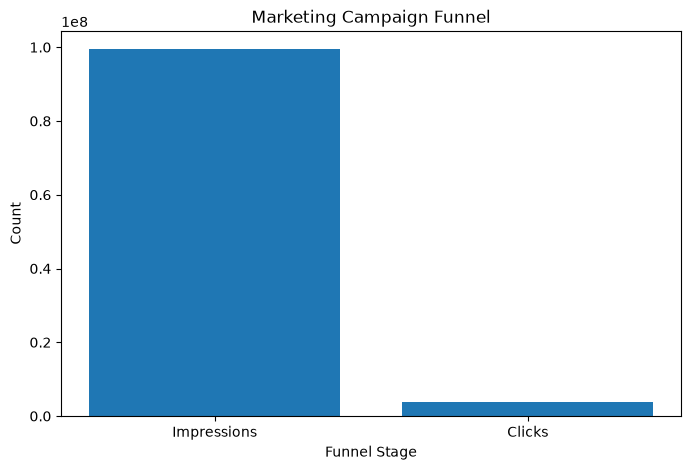

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(funnel["Stage"], funnel["Count"])

plt.title("Marketing Campaign Funnel")
plt.xlabel("Funnel Stage")
plt.ylabel("Count")

plt.savefig("marketing_funnel.png", dpi=300, bbox_inches="tight")
plt.show()

In [39]:
channel_summary = df.groupby("channel_name").agg(
    Impressions=("impressions", "sum"),
    Clicks=("clicks", "sum"),
    Media_Cost=("media_cost_usd", "sum")
).reset_index()

channel_summary

,channel_name,Impressions,Clicks,Media_Cost
0,Display,19563483,727444,167295.147682
1,Mobile,19967111,705995,174618.570802
2,Search,19869015,734676,171534.136191
3,Social,19965746,751933,172174.476811
4,Video,20042426,765860,171918.964851


In [40]:
channel_summary["CTR"] = (
    channel_summary["Clicks"] /
    channel_summary["Impressions"]
) * 100

channel_summary["CPC"] = (
    channel_summary["Media_Cost"] /
    channel_summary["Clicks"]
)

channel_summary["CPM"] = (
    channel_summary["Media_Cost"] /
    channel_summary["Impressions"]
) * 1000

In [41]:
channel_summary = channel_summary.round({
    "Impressions": 0,
    "Clicks": 0,
    "Media_Cost": 2,
    "CTR": 2,
    "CPC": 2,
    "CPM": 2
})

channel_summary

,channel_name,Impressions,Clicks,Media_Cost,CTR,CPC,CPM
0,Display,19563483,727444,167295.15,3.72,0.23,8.55
1,Mobile,19967111,705995,174618.57,3.54,0.25,8.75
2,Search,19869015,734676,171534.14,3.70,0.23,8.63
3,Social,19965746,751933,172174.48,3.77,0.23,8.62
4,Video,20042426,765860,171918.96,3.82,0.22,8.58


In [42]:
print("Highest CTR:")
print(channel_summary.loc[channel_summary["CTR"].idxmax()])

print("\nLowest CPC:")
print(channel_summary.loc[channel_summary["CPC"].idxmin()])

print("\nLowest CPM:")
print(channel_summary.loc[channel_summary["CPM"].idxmin()])

Highest CTR:
channel_name        Video
Impressions      20042426
Clicks             765860
Media_Cost      171918.96
CTR                  3.82
CPC                  0.22
CPM                  8.58
Name: 4, dtype: object

Lowest CPC:
channel_name        Video
Impressions      20042426
Clicks             765860
Media_Cost      171918.96
CTR                  3.82
CPC                  0.22
CPM                  8.58
Name: 4, dtype: object

Lowest CPM:
channel_name      Display
Impressions      19563483
Clicks             727444
Media_Cost      167295.15
CTR                  3.72
CPC                  0.23
CPM                  8.55
Name: 0, dtype: object


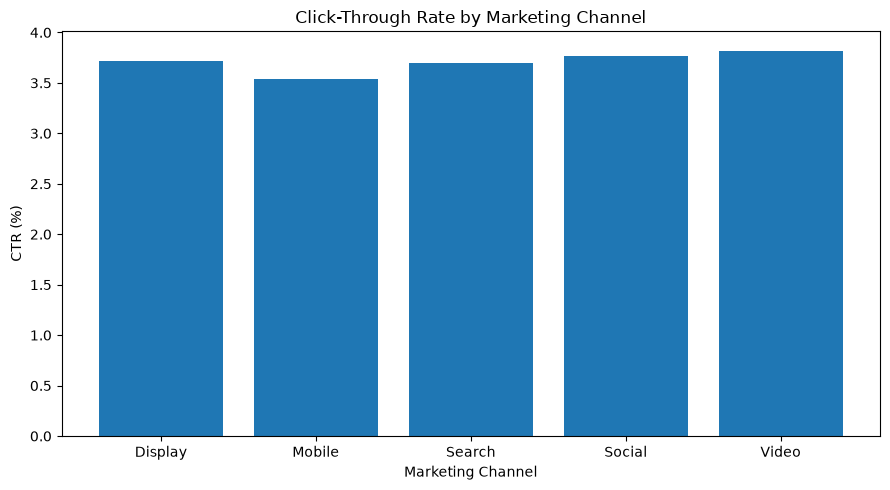

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(channel_summary["channel_name"], channel_summary["CTR"])

plt.title("Click-Through Rate by Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("CTR (%)")

plt.tight_layout()
plt.show()

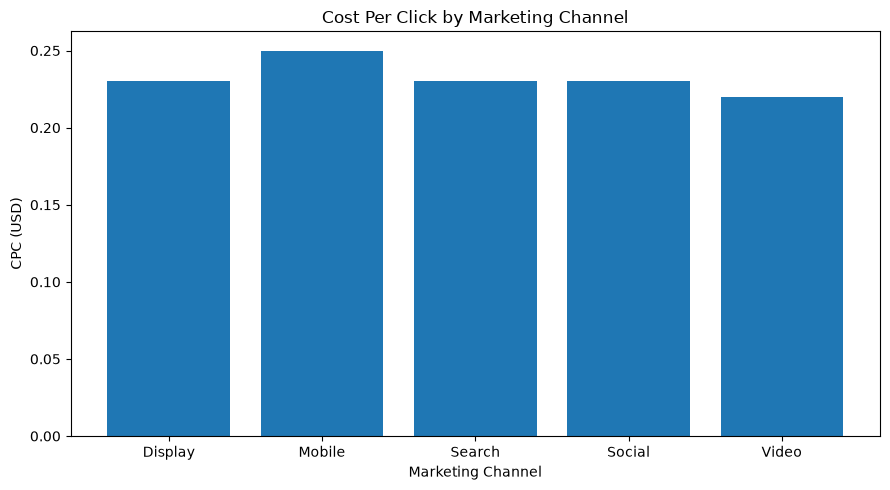

In [44]:
plt.figure(figsize=(9, 5))

plt.bar(channel_summary["channel_name"], channel_summary["CPC"])

plt.title("Cost Per Click by Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("CPC (USD)")

plt.tight_layout()
plt.show()

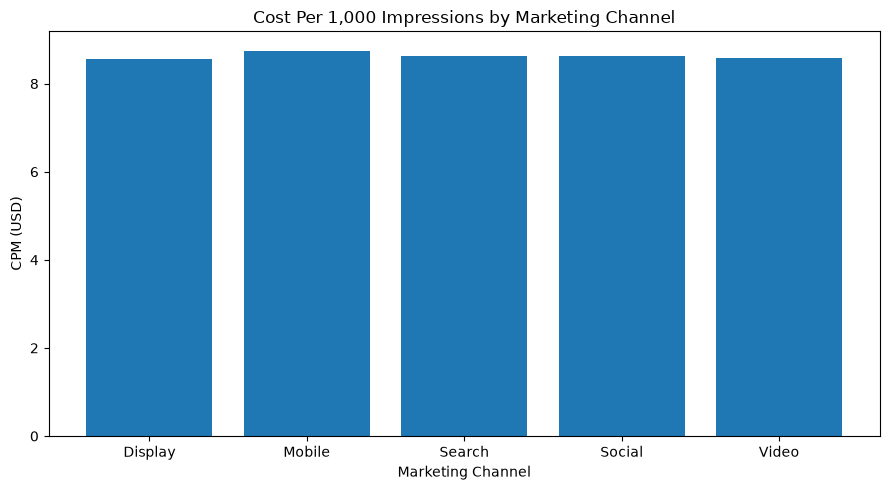

In [45]:
plt.figure(figsize=(9, 5))

plt.bar(channel_summary["channel_name"], channel_summary["CPM"])

plt.title("Cost Per 1,000 Impressions by Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("CPM (USD)")

plt.tight_layout()
plt.show()

In [46]:
print("===== PLATFORM INSIGHTS =====")

best_platform_ctr = platform_summary.loc[platform_summary["CTR"].idxmax(), "ext_service_name"]
best_platform_cpc = platform_summary.loc[platform_summary["CPC"].idxmin(), "ext_service_name"]
best_platform_cpm = platform_summary.loc[platform_summary["CPM"].idxmin(), "ext_service_name"]

print("Best CTR:", best_platform_ctr)
print("Lowest CPC:", best_platform_cpc)
print("Lowest CPM:", best_platform_cpm)


print("\n===== CHANNEL INSIGHTS =====")

best_channel_ctr = channel_summary.loc[channel_summary["CTR"].idxmax(), "channel_name"]
best_channel_cpc = channel_summary.loc[channel_summary["CPC"].idxmin(), "channel_name"]
best_channel_cpm = channel_summary.loc[channel_summary["CPM"].idxmin(), "channel_name"]

print("Best CTR:", best_channel_ctr)
print("Lowest CPC:", best_channel_cpc)
print("Lowest CPM:", best_channel_cpm)

===== PLATFORM INSIGHTS =====
Best CTR: DV360
Lowest CPC: DV360
Lowest CPM: Google Ads

===== CHANNEL INSIGHTS =====
Best CTR: Video
Lowest CPC: Video
Lowest CPM: Display


In [47]:
df.to_csv("Marketing_Campaign_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [48]:
import os
print(os.path.exists("Marketing_Campaign_Cleaned.csv"))

True


In [49]:
print("Final shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Final shape: (72603, 35)
Missing values: 0
Duplicate rows: 0
